![image](https://raw.githubusercontent.com/ambideXtrous9/Finetune-Qwen3-using-Unsloth/refs/heads/main/Experimental/Qwen3.5.jpg)


In [7]:
!nvidia-smi

Tue Mar 17 09:06:45 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   58C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## **🦥 Install Packages**

In [8]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth
else:
    # Do this only in Colab notebooks! Otherwise use pip install unsloth
    import torch; v = re.match(r"[0-9]{1,}\.[0-9]{1,}", str(torch.__version__)).group(0)
    xformers = "xformers==" + ("0.0.33.post1" if v=="2.9" else "0.0.32.post2" if v=="2.8" else "0.0.29.post3")
    !pip install --no-deps bitsandbytes accelerate {xformers} peft trl triton cut_cross_entropy unsloth_zoo
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth
!pip install transformers==4.56.2
!pip install --no-deps trl==0.22.2
!pip install -qq -U evaluate rouge_score

In [9]:
!pip install -qq --upgrade unsloth unsloth_zoo

In [10]:
import unsloth
from unsloth import FastLanguageModel, PatchFastRL
PatchFastRL("GRPO", FastLanguageModel)
import torch

/tmp/ipykernel_544/363605075.py:1: UserWarning: WARNING: Unsloth should be imported before [transformers] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  import unsloth


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


2026-03-17 09:07:06.181571: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773738426.203238     544 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773738426.209781     544 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773738426.228491     544 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773738426.228519     544 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773738426.228522     544 computation_placer.cc:177] computation placer alr

🦥 Unsloth Zoo will now patch everything to make training faster!
Unsloth: UnslothBCOTrainer is already patched.
Unsloth: UnslothCPOTrainer is already patched.
Unsloth: UnslothDPOTrainer is already patched.
Unsloth: UnslothGKDTrainer is already patched.
Unsloth: UnslothGRPOTrainer is already patched.
Unsloth: UnslothIterativeSFTTrainer is already patched.
Unsloth: UnslothKTOTrainer is already patched.
Unsloth: UnslothNashMDTrainer is already patched.
Unsloth: UnslothOnlineDPOTrainer is already patched.
Unsloth: UnslothORPOTrainer is already patched.
Unsloth: UnslothPPOTrainer is already patched.
Unsloth: UnslothPRMTrainer is already patched.
Unsloth: UnslothRewardTrainer is already patched.
Unsloth: UnslothRLOOTrainer is already patched.
Unsloth: UnslothSFTTrainer is already patched.
Unsloth: UnslothXPOTrainer is already patched.


In [11]:
from accelerate import Accelerator

from trl import GRPOConfig, GRPOTrainer
from unsloth import is_bfloat16_supported
import torch

import re
import torch
import numpy as np
import pandas as pd

import transformers
import statistics

seed = 2025

transformers.set_seed(seed)
torch.manual_seed(seed)

import os
os.environ["TOKENIZERS_PARALLELISM"] = "true"

# ── Disable Torch dynamo compilation ─────────────────────────────
# On Kaggle, torch.compile / dynamo fails during GRPO's chunked
# log-softmax because the symbolic batch dimensions of logits and
# index tensors don't match during fake-tensor tracing.
# Disabling dynamo forces eager execution — slightly slower but
# runs correctly on every platform.

import torch
import os

torch._dynamo.config.disable = True          # main switch
os.environ["TORCHDYNAMO_DISABLE"]  = "1"     # belt
os.environ["TORCH_COMPILE_DISABLE"] = "1"    # braces

# Also disable unsloth's own compilation cache which calls dynamo internally
os.environ["UNSLOTH_DISABLE_COMPILE"] = "1"

print(f"Dynamo disabled ✓  (torch {torch.__version__})")

Dynamo disabled ✓  (torch 2.9.0+cu126)


In [12]:
import os

In [13]:
max_seq_length = 1024

## **🦥 Loading Qwen3-0.6B Model**

In [14]:
# Load the base model and tokenizer
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Qwen3-0.6B",
    max_seq_length = max_seq_length,   # Define context length
    load_in_4bit = True,     # 4bit uses much less memory
    load_in_8bit = False,    # A bit more accurate, uses 2x memory
    full_finetuning = False, # We have full finetuning now!
    fast_inference = False,
    # token = "hf_...",      # Add your token if using a gated model
)

==((====))==  Unsloth 2026.3.4: Fast Qwen3 patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.5.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.33.post1. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
unsloth/qwen3-0.6b-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


In [15]:
model = FastLanguageModel.get_peft_model(
    model,
    r                          = 16,       # was 16 — quadruples trainable params
    target_modules             = ["q_proj", "k_proj", "v_proj", "o_proj",
                                  "gate_proj", "up_proj", "down_proj"],
    lora_alpha                 = 16,       # keep equal to r
    lora_dropout               = 0,
    bias                       = "none",
    use_gradient_checkpointing = "unsloth", # trades compute for memory
    random_state               = 3407,
)

Unsloth 2026.3.4 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


## **🦥 Loading GSM8K Dataset**

In [16]:
from datasets import load_dataset

# GSM8K = Grade School Math 8K
# 8,500 grade-school math word problems with step-by-step solutions.
# Each solution ends with "#### <number>" — the final answer.
# This is the standard benchmark used by GPT-4, Llama, DeepSeek, Qwen evals.

raw_train = load_dataset("openai/gsm8k", "main", split="train")
raw_test  = load_dataset("openai/gsm8k", "main", split="test")

print(f"Train size : {len(raw_train)}")   # 7473
print(f"Test  size : {len(raw_test)}")    # 1319

print("\n--- Sample row ---")
print("Question :", raw_train[0]["question"])
print("Answer   :", raw_train[0]["answer"])

Train size : 7473
Test  size : 1319

--- Sample row ---
Question : Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April and May?
Answer   : Natalia sold 48/2 = <<48/2=24>>24 clips in May.
Natalia sold 48+24 = <<48+24=72>>72 clips altogether in April and May.
#### 72


In [17]:
# GSM8K answers always end with "#### <integer>"
# We must extract ONLY that number as ground truth.
# Example answer string:
#   "Janet sells 16 - 3 - 4 = <<16-3-4=9>>9 eggs per day.
#    She makes 9 * 2 = <<9*2=18>>18 dollars per day.
#    #### 18"
# Ground truth = "18"
import re
def extract_gsm8k_ground_truth(answer_str):
    """
    Extract the final numeric answer after #### in GSM8K answers.
    Returns a clean string like "18" or "1.5".
    """
    match = re.search(r'####\s*([\d,\.\-]+)', answer_str)
    if match:
        # Remove commas: "1,000" → "1000"
        return match.group(1).replace(",", "").strip()
    return ""

# Verify on a few samples
for i in range(3):
    gt = extract_gsm8k_ground_truth(raw_train[i]["answer"])
    print(f"Sample {i} → ground truth: '{gt}'")

Sample 0 → ground truth: '72'
Sample 1 → ground truth: '10'
Sample 2 → ground truth: '5'


## **🦥 System Prompt Engineering**

In [18]:
# The system prompt is CRITICAL for GRPO on math.
# It tells the model:
#   1. HOW to structure its response (think block → solution → boxed answer)
#   2. WHAT format to use for the final answer (#### number)
#
# Our reward functions are designed around this exact format.
# Changing the system prompt requires changing the reward functions too.

SYSTEM_PROMPT = """You are an expert math problem solver.

When solving a problem, you MUST follow this exact structure:
1. Inside <think>...</think> tags: write your step-by-step reasoning.
2. After the think block: write a clean solution.
3. End with the final answer on its own line in this exact format:
   #### <number>

Example:
<think>
Total apples = 3 + 5 = 8
Each person gets 8 / 2 = 4
</think>
Each person receives 4 apples.
#### 4
"""

print("System prompt set.")
print(f"Character count: {len(SYSTEM_PROMPT)}")

System prompt set.
Character count: 423


## **🦥 Converting Dataset to GRPO Format**

In [45]:
def format_for_grpo(examples):
    """
    Converts raw GSM8K rows into GRPOTrainer-compatible format.

    Output columns:
      "prompt"        — list of message dicts (system + user turn only)
                        The model generates the assistant reply.
      "ground_truth"  — the numeric answer string (e.g. "18")
                        Passed automatically to reward functions as a kwarg.
    """
    prompts       = []
    ground_truths = []

    for question, answer in zip(examples["question"], examples["answer"]):
        prompts.append([
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user",   "content": question},
        ])
        ground_truths.append(extract_gsm8k_ground_truth(answer))

    return {
        "prompt"       : prompts,
        "ground_truth" : ground_truths,
    }

In [46]:
train_dataset = raw_train.map(
    format_for_grpo,
    batched      = True,
    num_proc     = 1,
    remove_columns = raw_train.column_names,
)

test_dataset = raw_test.map(
    format_for_grpo,
    batched      = True,
    num_proc     = 1,
    remove_columns = raw_test.column_names,
)

print(f"Train : {len(train_dataset)} prompts")
print(f"Test  : {len(test_dataset)} prompts")
print(f"\nSample prompt  : {train_dataset[0]['prompt'][1]['content'][:120]}...")
print(f"Ground truth   : '{train_dataset[0]['ground_truth']}'")

Train : 7473 prompts
Test  : 1319 prompts

Sample prompt  : Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natali...
Ground truth   : '72'


## **🦥 Token Distribution**

Train — n:  7473  mean: 170  std: 22  min: 122  max: 322  p95: 211
Test  — n:  1319  mean: 171  std: 22  min: 133  max: 298  p95: 215


/tmp/ipykernel_544/18601675.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


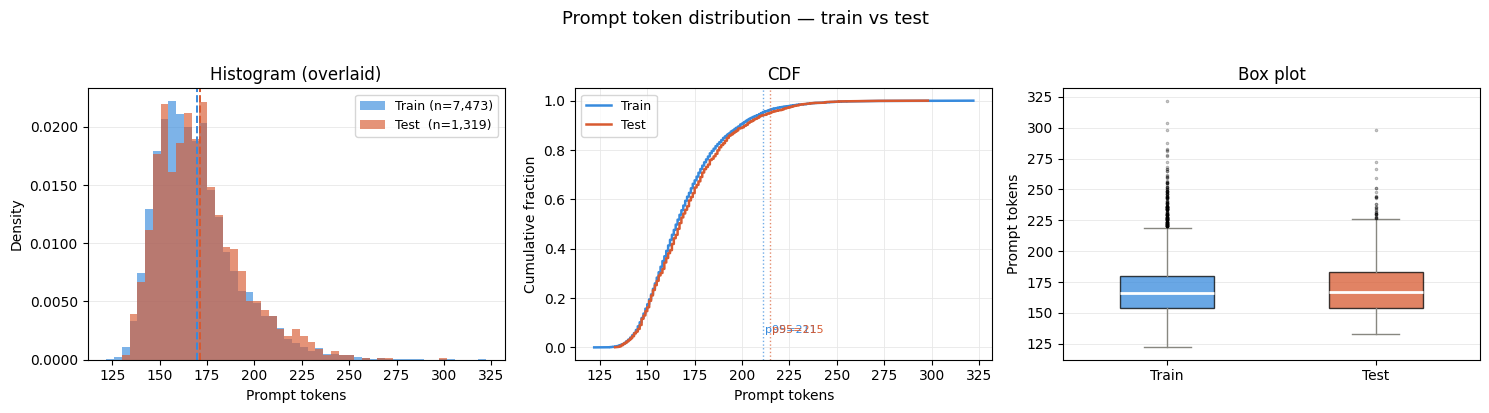

In [47]:
from transformers import AutoTokenizer
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── token counting ────────────────────────────────────────────────

def count_tokens(dataset, tokenizer):
    return np.array([
        len(tokenizer("\n".join(m["content"] for m in s["prompt"]))["input_ids"])
        for s in dataset
    ])

train_lens = count_tokens(train_dataset, tokenizer)
test_lens  = count_tokens(test_dataset,  tokenizer)

# ── stats ─────────────────────────────────────────────────────────
for name, lens in [("Train", train_lens), ("Test ", test_lens)]:
    print(
        f"{name} — n: {len(lens):>5}  mean: {lens.mean():.0f}  "
        f"std: {lens.std():.0f}  min: {lens.min()}  "
        f"max: {lens.max()}  p95: {np.percentile(lens, 95):.0f}"
    )

# ── plots ─────────────────────────────────────────────────────────
BLUE   = "#378ADD"
CORAL  = "#D85A30"
GRID   = "#e8e8e8"
ALPHA  = 0.65

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Prompt token distribution — train vs test", fontsize=13, y=1.02)

shared_bins = np.linspace(
    min(train_lens.min(), test_lens.min()),
    max(train_lens.max(), test_lens.max()),
    50,
)

# — panel 1: overlapping histograms —
ax = axes[0]
ax.hist(train_lens, bins=shared_bins, color=BLUE,  alpha=ALPHA, label=f"Train (n={len(train_lens):,})", density=True)
ax.hist(test_lens,  bins=shared_bins, color=CORAL, alpha=ALPHA, label=f"Test  (n={len(test_lens):,})",  density=True)
for name, lens, c in [("Train", train_lens, BLUE), ("Test", test_lens, CORAL)]:
    ax.axvline(lens.mean(), color=c, lw=1.4, ls="--")
ax.set_xlabel("Prompt tokens")
ax.set_ylabel("Density")
ax.set_title("Histogram (overlaid)")
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.4f"))
ax.grid(axis="y", color=GRID, linewidth=0.6)
ax.set_axisbelow(True)

# — panel 2: CDF —
ax = axes[1]
for name, lens, c in [("Train", train_lens, BLUE), ("Test", test_lens, CORAL)]:
    xs = np.sort(lens)
    ys = np.arange(1, len(xs) + 1) / len(xs)
    ax.plot(xs, ys, color=c, lw=1.8, label=name)
    p95 = np.percentile(lens, 95)
    ax.axvline(p95, color=c, lw=1, ls=":", alpha=0.7)
    ax.text(p95 + 1, 0.05, f"p95={p95:.0f}", color=c, fontsize=8, va="bottom")
ax.set_xlabel("Prompt tokens")
ax.set_ylabel("Cumulative fraction")
ax.set_title("CDF")
ax.legend(fontsize=9)
ax.grid(color=GRID, linewidth=0.6)
ax.set_axisbelow(True)

# — panel 3: box plots —
ax = axes[2]
bp = ax.boxplot(
    [train_lens, test_lens],
    labels=["Train", "Test"],
    patch_artist=True,
    medianprops=dict(color="white", linewidth=2),
    flierprops=dict(marker=".", markersize=3, alpha=0.3),
    widths=0.45,
)
for patch, c in zip(bp["boxes"], [BLUE, CORAL]):
    patch.set_facecolor(c)
    patch.set_alpha(0.75)
for whisker in bp["whiskers"]:
    whisker.set(color="#888780", linewidth=1)
for cap in bp["caps"]:
    cap.set(color="#888780", linewidth=1)
ax.set_ylabel("Prompt tokens")
ax.set_title("Box plot")
ax.grid(axis="y", color=GRID, linewidth=0.6)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("token_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [21]:
# Use a subset for demonstration.
# For a full production run: remove .select() and use the full 7473 train rows.

train_dataset = train_dataset.shuffle(seed=3407).select(range(1000))
valid_dataset = test_dataset.select(range(20))

print(f"Subset train : {len(train_dataset)}")
print(f"Subset valid : {len(valid_dataset)}")

Subset train : 1000
Subset valid : 20


## **🦥 Reward Functions**


In [22]:
# ================================================================
# REWARD UTILITY FUNCTIONS
# ================================================================
# These helpers are shared across multiple reward functions.
# Robust answer extraction is the single most important factor
# in reward quality — a buggy extractor creates a noisy signal
# that confuses the model and slows / breaks training.
# ================================================================

def extract_model_answer(text):
    """
    Extract the model's final answer from its generated text.
    Tries multiple formats in order of preference.

    Priority:
      1. #### <number>   — matches our system prompt instruction exactly
      2. \\boxed{<expr>} — fallback for LaTeX-style answers
      3. "answer is X"   — loose natural language fallback
      4. Last number     — last resort: grab the last number in the response

    Returns a normalised string like "18" or "1.5", or "" if nothing found.
    """
    # Strip think block first — don't accidentally match numbers inside reasoning
    text_no_think = re.sub(r'<think>.*?</think>', '', text, flags=re.DOTALL).strip()

    # Priority 1: #### format (matches our system prompt)
    m = re.search(r'####\s*([\-\d,\.]+)', text_no_think)
    if m:
        return m.group(1).replace(",", "").strip()

    # Priority 2: \boxed{} LaTeX notation
    m = re.search(r'\\boxed\{([^}]+)\}', text_no_think)
    if m:
        val = m.group(1).strip()
        # Handle \boxed{1{,}000} style (LaTeX thousands separator)
        val = re.sub(r'\{,\}', '', val)
        return val.replace(",", "").strip()

    # Priority 3: "the answer is X" / "= X" at end of sentence
    m = re.search(
        r'(?:answer is|answer:|result is|=)\s*([\-\d,\.]+)',
        text_no_think, re.IGNORECASE
    )
    if m:
        return m.group(1).replace(",", "").strip()

    # Priority 4: Last number in the response (last resort)
    numbers = re.findall(r'[\-]?\d+(?:\.\d+)?', text_no_think)
    if numbers:
        return numbers[-1]

    return ""


def normalise_number(s):
    """
    Normalise a numeric string for comparison.
    Handles: integers, floats, negative numbers, trailing zeros.

    "18.0" == "18" == "18.00" → True
    "1000" == "1,000"         → True  (commas stripped before this call)
    """
    s = s.strip().replace(",", "")
    try:
        val = float(s)
        # If it's a whole number, compare as int to avoid 18 != 18.0
        if val == int(val):
            return str(int(val))
        return f"{val:.4f}".rstrip('0').rstrip('.')
    except ValueError:
        return s.lower()


# Sanity checks
print("Extraction tests:")
print(extract_model_answer("After solving: #### 42"))                    # "42"
print(extract_model_answer("So the answer is \\boxed{1000}"))            # "1000"
print(extract_model_answer("<think>3+5=8</think>The answer is 8\n#### 8"))  # "8"

print("\nNormalisation tests:")
print(normalise_number("18.0") == normalise_number("18"))   # True
print(normalise_number("1000") == normalise_number("1000")) # True

Extraction tests:
42
1000
8

Normalisation tests:
True
True


In [23]:
def reward_correctness(completions, ground_truth=None, **kwargs):
    """
    REWARD 1 — Mathematical Correctness
    ════════════════════════════════════
    Weight: HIGH  |  Range: 0.0 – 2.0

    This is the PRIMARY learning signal.
    All other rewards are secondary regulators.

    Scoring:
      +2.0  Extracted answer matches ground truth (normalised comparison)
       0.0  Wrong answer or no answer found

    Design notes:
    ─────────────
    • We normalise both sides before comparing: "18.0" == "18" == "18.00"
    • We strip commas: "1,000" == "1000"
    • We strip the <think> block before extracting — prevents the model
      from hiding a correct answer inside its reasoning and never
      stating it in the response body (reward hacking)
    """
    rewards = []
    for i, completion in enumerate(completions):
        text = completion[0]["content"]
        predicted = normalise_number(extract_model_answer(text))

        if ground_truth and i < len(ground_truth):
            expected = normalise_number(str(ground_truth[i]))
            rewards.append(2.0 if predicted == expected and predicted != "" else 0.0)
        else:
            rewards.append(0.0)
    return rewards


# Test
_c  = [[{"content": "<think>3+3=6</think> so it's 6\n#### 6"}],
        [{"content": "#### 7"}],
        [{"content": "I'm not sure"}]]
_gt = ["6", "6", "6"]
print("Correctness:", reward_correctness(_c, ground_truth=_gt))
# Expected: [2.0, 0.0, 0.0]

Correctness: [2.0, 0.0, 0.0]


In [24]:
def reward_format(completions, **kwargs):
    """
    REWARD 2 — Structural Format Compliance
    ════════════════════════════════════════
    Weight: MEDIUM  |  Range: -0.5 – 1.0

    Enforces the response structure defined in the system prompt:
      <think>…</think>  →  solution text  →  #### <number>

    Why this matters:
    ─────────────────
    Without a format reward, the model may give correct answers but
    in inconsistent formats — making downstream extraction unreliable
    and the correctness reward noisy.

    Scoring breakdown:
      +0.5  <think>…</think> block present and properly closed
      +0.5  #### <number> present at the end
      -0.5  <think> opened but never closed (malformed output)
      -0.5  Response ends with reasoning but no #### answer line
             (model stopped mid-generation or forgot the format)

    Scores are additive — a perfect response scores +1.0.
    """
    rewards = []
    for completion in completions:
        text  = completion[0]["content"]
        score = 0.0

        # ── Think block check ────────────────────────────────────
        has_open  = "<think>"  in text
        has_close = "</think>" in text

        if has_open and has_close:
            score += 0.5    # Well-formed reasoning block
        elif has_open and not has_close:
            score -= 0.5    # Opened but never closed → malformed

        # ── Final answer line check ──────────────────────────────
        # Must appear AFTER the think block (if any)
        text_after_think = re.sub(r'<think>.*?</think>', '', text, flags=re.DOTALL)
        has_hash_answer  = bool(re.search(r'####\s*[\-\d]', text_after_think))

        if has_hash_answer:
            score += 0.5    # Correct answer format present
        else:
            score -= 0.5    # No structured final answer

        rewards.append(score)
    return rewards


# Test
_c = [[{"content": "<think>step</think>Done\n#### 5"}],   # perfect
      [{"content": "<think>step"}],                        # unclosed think
      [{"content": "The answer is five."}]]                # no #### at all
print("Format:", reward_format(_c))
# Expected: [1.0, -0.5, -0.5]

Format: [1.0, -1.0, -0.5]


In [25]:
def reward_reasoning_quality(completions, **kwargs):
    """
    REWARD 3 — Reasoning Chain Quality
    ════════════════════════════════════
    Weight: MEDIUM  |  Range: 0.0 – 1.0

    Checks whether the think block contains REAL mathematical reasoning,
    not just filler text or a copy of the question.

    Why this matters:
    ─────────────────
    Without this, the model can game reward_format by writing:
      <think>ok</think> #### 5
    This gets the format reward but does zero actual reasoning.
    reward_reasoning_quality penalises empty or trivial think blocks.

    Scoring:
      +0.3  Think block exists and is non-trivial (> 30 chars)
      +0.3  Contains arithmetic operations: =, +, -, *, /, numbers
      +0.2  Multiple reasoning steps (≥ 2 newlines inside think block)
      +0.2  Think block substantially shorter than full response
             (model is not just dumping everything into the think block)

    Total: 0.0 – 1.0
    """
    rewards = []
    for completion in completions:
        text  = completion[0]["content"]
        score = 0.0

        think_match = re.search(r'<think>(.*?)</think>', text, re.DOTALL)
        if not think_match:
            rewards.append(0.0)
            continue

        think_content = think_match.group(1).strip()

        # ── Check 1: non-trivial length ─────────────────────────
        if len(think_content) > 30:
            score += 0.3

        # ── Check 2: arithmetic content ─────────────────────────
        has_arithmetic = bool(re.search(
            r'[\+\-\*\/=]|\d+\s*[\+\-\*\/]\s*\d+',
            think_content
        ))
        if has_arithmetic:
            score += 0.3

        # ── Check 3: multi-step reasoning ───────────────────────
        steps = [l for l in think_content.split('\n') if l.strip()]
        if len(steps) >= 2:
            score += 0.2

        # ── Check 4: think block ≠ whole response ───────────────
        think_ratio = len(think_content) / max(len(text), 1)
        if think_ratio < 0.85:  # Think block is not 85%+ of the response
            score += 0.2

        rewards.append(round(score, 3))
    return rewards


# Test
_c = [[{"content": "<think>3 * 5 = 15\n15 + 2 = 17</think>\n#### 17"}],   # good
      [{"content": "<think>ok</think>\n#### 5"}],                           # trivial
      [{"content": "#### 5"}]]                                              # no think
print("Reasoning quality:", reward_reasoning_quality(_c))
# Expected: [1.0, 0.0–0.3, 0.0]

Reasoning quality: [0.7, 0.2, 0.0]


In [26]:
def reward_no_hacking(completions, ground_truth=None, **kwargs):
    """
    REWARD 4 — Anti-Gaming / Reward Hacking Prevention
    ════════════════════════════════════════════════════
    Weight: LOW  |  Range: -1.0 – 0.0  (penalty only)

    Detects known reward-hacking strategies and penalises them.
    This reward should ALWAYS be 0.0 for a clean response.

    Hacks we catch:
    ───────────────
    A) Answer repetition:
       Model writes #### 5 multiple times hoping one matches.
       Detected: > 1 occurrence of "####" in the response.
       Penalty: -0.5

    B) Enumeration fishing:
       Model lists many candidate answers: "#### 1, #### 2, ... #### 42"
       Detected: more than 2 distinct numbers after ####.
       Penalty: -0.5 (additive with A if both triggered)

    C) Think-block stuffing the answer:
       Model hides the correct number inside <think> and writes
       a different (wrong) number after ####, confusing extractors.
       Detected: ground_truth appears inside <think> but #### answer is wrong.
       Penalty: -0.5

    D) Extreme length padding:
       Response > 800 words usually means repetitive padding.
       Penalty: -0.3 per 200 words over the limit (capped at -0.5)
    """
    rewards = []
    for i, completion in enumerate(completions):
        text   = completion[0]["content"]
        penalty = 0.0

        # ── Hack A: multiple #### lines ─────────────────────────
        hash_answers = re.findall(r'####\s*([\-\d,\.]+)', text)
        if len(hash_answers) > 1:
            penalty -= 0.5

        # ── Hack B: enumeration fishing ─────────────────────────
        unique_answers = set(a.replace(",","") for a in hash_answers)
        if len(unique_answers) > 2:
            penalty -= 0.5

        # ── Hack C: answer stuffed inside think block ───────────
        if ground_truth and i < len(ground_truth):
            gt = normalise_number(str(ground_truth[i]))
            think_match = re.search(r'<think>(.*?)</think>', text, re.DOTALL)
            if think_match:
                think_text  = think_match.group(1)
                after_think = re.sub(r'<think>.*?</think>', '', text, flags=re.DOTALL)
                extracted_final = normalise_number(extract_model_answer(after_think))
                gt_in_think     = gt in think_text
                final_wrong     = extracted_final != gt
                if gt_in_think and final_wrong:
                    penalty -= 0.5   # Answer was in think but not stated properly

        # ── Hack D: extreme padding ──────────────────────────────
        word_count = len(text.split())
        if word_count > 800:
            excess  = (word_count - 800) // 200
            penalty -= min(0.5, 0.3 * excess)

        rewards.append(round(penalty, 3))
    return rewards


# Test
_c  = [[{"content": "#### 5\n#### 5\n#### 5"}],          # Hack A: repeated answers
        [{"content": "<think>42</think>\n#### 7"}],        # Hack C: answer in think
        [{"content": "<think>5+3=8</think>\n#### 8"}]]     # Clean response
_gt = ["5", "42", "8"]
print("Anti-hacking:", reward_no_hacking(_c, ground_truth=_gt))
# Expected: [-0.5, -0.5, 0.0]

Anti-hacking: [-0.5, -0.5, 0.0]


In [27]:
def reward_numeric_proximity(completions, ground_truth=None, **kwargs):
    """
    REWARD 5 — Numeric Proximity (Partial Credit)
    ══════════════════════════════════════════════
    Weight: LOW  |  Range: 0.0 – 0.5

    Gives partial credit when the model is "close" to the right answer.
    This prevents the reward signal from being completely binary (0 or 2)
    and gives the model a gradient to follow when it's almost correct.

    Why it helps:
    ─────────────
    With only reward_correctness, a model that answers 99 instead of 100
    gets exactly the same reward (0.0) as a model that answers 999.
    This is a very sparse gradient. Proximity reward adds a soft signal.

    Scoring:
      +0.5  Exact match        (same as getting +2.0 from correctness)
      +0.3  Within 1% of GT    e.g., GT=100, model=99  → diff=1%
      +0.2  Within 5% of GT    e.g., GT=100, model=95
      +0.1  Within 20% of GT   e.g., GT=100, model=82
       0.0  Off by > 20% or non-numeric answer

    NOTE: This reward is intentionally small (max 0.5) so it never
    outweighs reward_correctness (max 2.0). It is a soft nudge only.
    """
    rewards = []
    for i, completion in enumerate(completions):
        text = completion[0]["content"]
        predicted_str = extract_model_answer(text)

        if not ground_truth or i >= len(ground_truth):
            rewards.append(0.0)
            continue

        try:
            predicted = float(normalise_number(predicted_str))
            expected  = float(normalise_number(str(ground_truth[i])))
        except (ValueError, TypeError):
            rewards.append(0.0)
            continue

        # Exact match
        if predicted == expected:
            rewards.append(0.5)
            continue

        # Relative error
        if expected != 0:
            rel_err = abs(predicted - expected) / abs(expected)
        else:
            rel_err = abs(predicted - expected)

        if rel_err <= 0.01:
            rewards.append(0.3)
        elif rel_err <= 0.05:
            rewards.append(0.2)
        elif rel_err <= 0.20:
            rewards.append(0.1)
        else:
            rewards.append(0.0)

    return rewards


# Test
_c  = [[{"content": "#### 100"}],   # exact
        [{"content": "#### 99"}],    # within 1%
        [{"content": "#### 80"}],    # within 20%
        [{"content": "#### 10"}]]    # way off
_gt = ["100", "100", "100", "100"]
print("Proximity:", reward_numeric_proximity(_c, ground_truth=_gt))
# Expected: [0.5, 0.3, 0.1, 0.0]

Proximity: [0.5, 0.3, 0.1, 0.0]


In [28]:
def reward_conciseness(completions, **kwargs):
    """
    REWARD 6 — Conciseness
    ═══════════════════════
    Weight: LOW  |  Range: -0.3 – 0.3

    GSM8K problems have short, definitive answers.
    A well-reasoned response should be 60–400 words.
    We penalise both extremes:
      Too short → model gave up or guessed
      Too long  → model is padding or looping

    This works together with reward_no_hacking:
      reward_no_hacking catches extreme padding (>800 words)
      reward_conciseness provides a smoother gradient for normal lengths

    Scoring (by word count of full response):
       60–400 words  → +0.3  (ideal)
       40–59  words  → +0.1  (a little short but ok)
      400–600 words  → +0.1  (a little long but ok)
       <40    words  → -0.3  (too short — likely gave up)
       >600   words  → -0.2  (too long — likely padding)
    """
    rewards = []
    for completion in completions:
        text  = completion[0]["content"]
        words = len(text.split())

        if 60 <= words <= 400:
            rewards.append(0.3)
        elif 40 <= words < 60:
            rewards.append(0.1)
        elif 400 < words <= 600:
            rewards.append(0.1)
        elif words < 40:
            rewards.append(-0.3)
        else:
            rewards.append(-0.2)
    return rewards

## **🦥 Reward calculation on Sample Data**

In [29]:
# Full end-to-end reward test on a realistic model output

sample_perfect = [[{"content": """<think>
Janet has 16 eggs per day.
She eats 3 for breakfast: 16 - 3 = 13
She bakes muffins using 4: 13 - 4 = 9
She sells 9 eggs per day.
Each egg sold for $2: 9 * 2 = 18 dollars
</think>
Janet makes $18 per day at the farmers market.
#### 18"""}]]

sample_wrong = [[{"content": """<think>
16 - 3 = 13, then 13 - 4 = 9
</think>
#### 20"""}]]

sample_hack = [[{"content": "#### 18\n#### 18\n#### 18"}]]

gt = ["18", "18", "18"]

all_completions = [sample_perfect[0], sample_wrong[0], sample_hack[0]]
all_gt          = gt

print("=" * 55)
print(f"{'Reward':<28} {'Perfect':>8} {'Wrong':>8} {'Hack':>8}")
print("-" * 55)

fns = [
    ("Correctness  (×2.0)",  reward_correctness),
    ("Format       (×1.0)",  reward_format),
    ("Reasoning    (×1.0)",  reward_reasoning_quality),
    ("Anti-hack    (×1.0)",  reward_no_hacking),
    ("Proximity    (×0.5)",  reward_numeric_proximity),
    ("Conciseness  (×0.3)",  reward_conciseness),
]

totals = [0.0, 0.0, 0.0]
for name, fn in fns:
    r = fn(all_completions, ground_truth=all_gt)
    totals = [totals[j] + r[j] for j in range(3)]
    print(f"  {name:<26} {r[0]:>8.2f} {r[1]:>8.2f} {r[2]:>8.2f}")

print("-" * 55)
print(f"  {'TOTAL':<26} {totals[0]:>8.2f} {totals[1]:>8.2f} {totals[2]:>8.2f}")
print(f"  {'MAX POSSIBLE':>52}: ~5.1")
print("=" * 55)

Reward                        Perfect    Wrong     Hack
-------------------------------------------------------
  Correctness  (×2.0)            2.00     0.00     2.00
  Format       (×1.0)            1.00     1.00     0.50
  Reasoning    (×1.0)            1.00     0.50     0.00
  Anti-hack    (×1.0)            0.00     0.00    -0.50
  Proximity    (×0.5)            0.50     0.10     0.50
  Conciseness  (×0.3)            0.10    -0.30    -0.30
-------------------------------------------------------
  TOTAL                          4.60     1.30     2.20
                                          MAX POSSIBLE: ~5.1


## **🦥 GRPO Training Args**

In [30]:
grpo_config = GRPOConfig(
    num_generations             = 4,
    max_completion_length       = 512,
    beta                        = 0.04,
    per_device_train_batch_size = 4,
    per_device_eval_batch_size  = 4,
    gradient_accumulation_steps = 2,
    warmup_steps                = 20,
    max_steps                   = 5,
    learning_rate               = 5e-6,
    optim                       = "adamw_8bit",
    weight_decay                = 0.01,
    max_grad_norm               = 0.1,
    lr_scheduler_type           = "cosine",
    fp16                        = not torch.cuda.is_bf16_supported(),
    bf16                        = torch.cuda.is_bf16_supported(),
    use_vllm                    = False,
    use_transformers_paged      = False,
    temperature                 = 0.7,
    top_p                       = 0.9,
    top_k                       = 50,
    logging_steps               = 1,
    save_steps                  = 50,
    output_dir                  = "grpo_gsm8k_qwen3_outputs",
    report_to                   = "none",
    eval_strategy               = "steps",
    eval_steps                  = 5,
    seed                        = 3407,
)

## **🦥 GRPO Callback**

In [48]:
import torch
import numpy as np
from transformers import TrainerCallback
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction


class GRPOMetricsCallback(TrainerCallback):
    """
    GRPO training logger: per-step VRAM / reward / KL +
    eval-time accuracy / ROUGE-1 / ROUGE-L / BLEU via generation.

    Args:
        eval_dataset  : list of {"prompt": str, "answer": str} dicts
        tokenizer     : tokenizer for encoding prompts / decoding outputs
        max_new_tokens: generation cap during eval (default 256)

    Deps:  pip install rouge-score nltk
           python -c "import nltk; nltk.download('punkt')"
    """

    COLUMNS = [
        # (log_key,                              header,  width)
        ("loss",                                 "Loss",     8),
        ("reward",                               "Reward",   8),
        ("reward_std",                           "RwdStd",   8),
        ("kl",                                   "KL",       7),
        ("completions/mean_length",              "Len",      6),
        ("completions/clipped_ratio",            "Clipped",  8),
        ("rewards/reward_correctness/mean",      "Corr",     7),
        ("rewards/reward_format/mean",           "Fmt",      7),
        ("rewards/reward_reasoning_quality/mean","Rsn",      7),
        ("rewards/reward_no_hacking/mean",       "Hack",     7),
        ("rewards/reward_numeric_proximity/mean","Prox",     7),
        ("rewards/reward_conciseness/mean",      "Conc",     7),
        ("eval_loss",                            "ValLoss",  8),
        ("eval_accuracy",                        "Acc",      7),
        ("eval_rouge1",                          "Rouge1",   7),
        ("eval_rougeL",                          "RougeL",   7),
        ("eval_bleu",                            "BLEU",     7),
    ]

    STEP_W = 6
    VRAM_W = 14

    def __init__(self, eval_dataset=None, tokenizer=None, max_new_tokens=256):
        self._header_printed = False
        self._buffer         = {}
        self._model          = None   # cached from on_evaluate for use in on_log
        self.eval_dataset    = eval_dataset
        self.tokenizer       = tokenizer
        self.max_new_tokens  = max_new_tokens
        self._rouge          = rouge_scorer.RougeScorer(
            ["rouge1", "rougeL"], use_stemmer=True
        )

    # ── Formatting ────────────────────────────────────────────────

    def _print_header(self):
        header = f"{'Step':>{self.STEP_W}}  {'VRAM':>{self.VRAM_W}}"
        sep    = "-" * self.STEP_W + "  " + "-" * self.VRAM_W
        for _, name, w in self.COLUMNS:
            header += f"  {name:>{w}}"
            sep    += "  " + "-" * w
        print("\n" + header + "\n" + sep)
        self._header_printed = True

    @staticmethod
    def _fmt(v, w):
        if v is None:
            return f"{'---':>{w}}"
        if isinstance(v, float):
            if v != 0.0 and abs(v) < 1e-3:
                return f"{v:>{w}.2e}"
            return f"{v:>{w}.4f}"
        return f"{str(v):>{w}}"

    @staticmethod
    def _vram():
        if not torch.cuda.is_available():
            return "N/A"
        used  = torch.cuda.memory_allocated() / 1e9
        total = torch.cuda.get_device_properties(0).total_memory / 1e9
        return f"{used:.1f}/{total:.0f}G {used / total * 100:.0f}%"

    # ── Generation metrics ────────────────────────────────────────

    def _compute_gen_metrics(self):
        """Run greedy generation on eval_dataset, return accuracy/ROUGE/BLEU."""
        if not self.eval_dataset or self.tokenizer is None or self._model is None:
            return {}

        self._model.eval()
        preds, refs = [], []

        with torch.no_grad():
            for item in self.eval_dataset:
                enc = self.tokenizer(
                    item["prompt"], return_tensors="pt"
                ).to(self._model.device)
                out = self._model.generate(
                    **enc,
                    max_new_tokens=self.max_new_tokens,
                    do_sample=False,
                )
                pred = self.tokenizer.decode(
                    out[0][enc["input_ids"].shape[1]:],
                    skip_special_tokens=True,
                )
                preds.append(pred.strip())
                refs.append(item["answer"].strip())

        accuracy = sum(p == r for p, r in zip(preds, refs)) / len(refs)

        r1, rl = [], []
        for p, r in zip(preds, refs):
            s = self._rouge.score(r, p)
            r1.append(s["rouge1"].fmeasure)
            rl.append(s["rougeL"].fmeasure)

        bleu = corpus_bleu(
            [[r.split()] for r in refs],
            [p.split()   for p in preds],
            smoothing_function=SmoothingFunction().method1,
        )

        return {
            "eval_accuracy": accuracy,
            "eval_rouge1":   float(np.mean(r1)),
            "eval_rougeL":   float(np.mean(rl)),
            "eval_bleu":     float(bleu),
        }

    # ── Row flushing ──────────────────────────────────────────────

    def _flush(self, step, is_eval=False):
        if not self._header_printed:
            self._print_header()
        logs = self._buffer.pop(step, {})
        row  = f"{step:>{self.STEP_W}}  {self._vram():>{self.VRAM_W}}"
        for key, _, w in self.COLUMNS:
            row += "  " + self._fmt(logs.get(key), w)
        print(row)
        if is_eval:
            print()

    def _is_eval_step(self, step, args):
        eval_steps = getattr(args, "eval_steps", None)
        strategy   = getattr(args, "eval_strategy", "no")
        return strategy != "no" and eval_steps and step % eval_steps == 0

    # ── Trainer hooks ─────────────────────────────────────────────

    def on_train_begin(self, args, state, control, model=None, **kwargs):
        """Cache model reference once at train start — on_evaluate does NOT
        receive model as a kwarg in TRL's GRPOTrainer."""
        if model is not None:
            self._model = model

    def on_evaluate(self, args, state, control, model=None, **kwargs):
        """Fallback capture in case a non-GRPO trainer passes model here."""
        if model is not None:
            self._model = model

    def on_log(self, args, state, control, logs=None, **kwargs):
        if not logs:
            return

        step = state.global_step
        self._buffer.setdefault(step, {}).update(logs)

        if "eval_loss" in logs:
            # Eval log arrived.  Compute gen metrics NOW (model already cached
            # by on_evaluate, which always fires before on_log in the Trainer
            # loop).  Update the buffer before flushing so everything lands on
            # one row.
            gen = self._compute_gen_metrics()
            if gen:
                self._buffer[step].update(gen)
            self._flush(step, is_eval=True)

        elif not self._is_eval_step(step, args):
            # Pure training step — flush immediately.
            self._flush(step)
        # else: train log on an eval step — wait for eval_loss in the next
        # on_log call before flushing.

    def on_train_end(self, args, state, control, **kwargs):
        # Drain anything left (e.g. final step if eval never fired).
        for step in sorted(self._buffer.keys()):
            self._flush(step)
        print("\n" + "=" * 40 + "\nTraining complete.\n" + "=" * 40)

In [49]:
eval_callback = GRPOMetricsCallback()

## **🦥 GRPO Trainer**

In [50]:
from transformers.trainer_callback import PrinterCallback
from transformers import ProgressCallback

trainer = GRPOTrainer(
    model         = model,
    tokenizer     = tokenizer,
    args          = grpo_config,
    train_dataset = train_dataset,
    eval_dataset  = valid_dataset,
    reward_funcs  = [
        reward_correctness,
        reward_format,
        reward_reasoning_quality,
        reward_no_hacking,
        reward_numeric_proximity,
        reward_conciseness,
    ],
    callbacks = [eval_callback],
)

# Strip default HF table + printer — must be AFTER init
trainer.remove_callback(ProgressCallback)
trainer.remove_callback(PrinterCallback)

print("Active callbacks:", [type(c).__name__ for c in trainer.callback_handler.callbacks])

Active callbacks: ['DefaultFlowCallback', 'GRPOMetricsCallback', 'NotebookProgressCallback']


## **🦥 Compute loss on Response Only**

In [51]:
import torch

def print_vram():
    used  = torch.cuda.memory_allocated() / 1e9
    total = torch.cuda.get_device_properties(0).total_memory / 1e9
    pct   = used / total * 100
    print(f"VRAM: {used:.1f} / {total:.1f} GB  ({pct:.1f}%)")

print_vram()  # call before trainer.train() to see baseline

VRAM: 0.8 / 15.6 GB  (5.0%)


In [52]:
print("Starting GRPO training on GSM8K...")
print("Watch: rewards/mean ↑   |   objective/kl < 5.0\n")

trainer_stats = trainer.train()

print("\nTraining complete.")
print(trainer_stats)

Starting GRPO training on GSM8K...
Watch: rewards/mean ↑   |   objective/kl < 5.0



==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 7,473 | Num Epochs = 1 | Total steps = 5
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 2 x 1) = 8
 "-____-"     Trainable parameters = 10,092,544 of 606,142,464 (1.67% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,Validation Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / reward_correctness / mean,rewards / reward_correctness / std,rewards / reward_format / mean,rewards / reward_format / std,rewards / reward_reasoning_quality / mean,rewards / reward_reasoning_quality / std,rewards / reward_no_hacking / mean,rewards / reward_no_hacking / std,rewards / reward_numeric_proximity / mean,rewards / reward_numeric_proximity / std,rewards / reward_conciseness / mean,rewards / reward_conciseness / std
5,0.000000,0.000006,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0



  Step            VRAM      Loss    Reward    RwdStd       KL     Len   Clipped     Corr      Fmt      Rsn     Hack     Prox     Conc   ValLoss      Acc   Rouge1   RougeL     BLEU
------  --------------  --------  --------  --------  -------  ------  --------  -------  -------  -------  -------  -------  -------  --------  -------  -------  -------  -------
     1      0.7/16G 4%    0.0000   -0.7000    0.0000  1.33e-05  512.0000    1.0000   0.0000  -1.0000   0.0000   0.0000   0.0000   0.3000       ---      ---      ---      ---      ---
     2      0.7/16G 4%    0.0000    2.1625    0.4732  9.20e-05  405.7500    0.0000   0.2500   0.8750   0.8000  -0.1250   0.0625   0.3000       ---      ---      ---      ---      ---
     3      0.7/16G 4%    0.0000    0.6375    1.0978  4.90e-05  497.3750    0.7500   0.2500  -0.1250   0.4000  -0.2500   0.0625   0.3000       ---      ---      ---      ---      ---
     4      0.7/16G 4%    0.0000    0.4750    1.4297  8.27e-05  477.3750    0.7500   0.500

In [54]:
# print training stats
print(trainer_stats)

TrainOutput(global_step=5, training_loss=2.8955001653230284e-06, metrics={'train_runtime': 1041.4459, 'train_samples_per_second': 0.038, 'train_steps_per_second': 0.005, 'total_flos': 0.0, 'train_loss': 2.8955001653230284e-06})


In [55]:
print("=== GRPO GSM8K Training Summary ===")
metrics = trainer_stats.metrics
print(f"  Runtime           : {metrics['train_runtime']:.1f}s "
      f"({metrics['train_runtime']/60:.1f} min)")
print(f"  Samples/sec       : {metrics['train_samples_per_second']:.2f}")
print(f"  Steps/sec         : {metrics['train_steps_per_second']:.4f}")
print(f"  Final train loss  : {metrics.get('train_loss', 'N/A')}")

=== GRPO GSM8K Training Summary ===
  Runtime           : 1041.4s (17.4 min)
  Samples/sec       : 0.04
  Steps/sec         : 0.0050
  Final train loss  : 2.8955001653230284e-06


## **🦥 Streaming Inference**

In [56]:
from transformers import TextStreamer

test_problem = (
    "A store sells apples for $1.50 each and oranges for $2.00 each. "
    "Tom buys 4 apples and 3 oranges. How much does he spend in total?"
)

messages_no_think = [
    {"role": "system", "content": SYSTEM_PROMPT},
    {"role": "user",   "content": test_problem},
]

text_no_think = tokenizer.apply_chat_template(
    messages_no_think,
    tokenize              = False,
    add_generation_prompt = True,
    enable_thinking       = False,
)

print("--- Non-Thinking Prompt ---")
print(text_no_think)

--- Non-Thinking Prompt ---
<|im_start|>system
You are an expert math problem solver.

When solving a problem, you MUST follow this exact structure:
1. Inside <think>...</think> tags: write your step-by-step reasoning.
2. After the think block: write a clean solution.
3. End with the final answer on its own line in this exact format:
   #### <number>

Example:
<think>
Total apples = 3 + 5 = 8
Each person gets 8 / 2 = 4
</think>
Each person receives 4 apples.
#### 4
<|im_end|>
<|im_start|>user
A store sells apples for $1.50 each and oranges for $2.00 each. Tom buys 4 apples and 3 oranges. How much does he spend in total?<|im_end|>
<|im_start|>assistant
<think>

</think>




In [57]:
inputs   = tokenizer(text_no_think, return_tensors="pt").to("cuda")
streamer = TextStreamer(tokenizer, skip_prompt=True)

_ = model.generate(
    **inputs,
    max_new_tokens = 256,
    temperature    = 0.7,
    top_p          = 0.8,
    top_k          = 20,
    streamer       = streamer,
    eos_token_id   = tokenizer.eos_token_id,
)
print("\n---------------------------")

We need to calculate the total cost of Tom's purchase of 4 apples and 3 oranges.

- The cost of 1 apple is $1.50.
- The cost of 1 orange is $2.00.

Tom buys 4 apples, so the cost of the apples is:
$$ 4 \times 1.50 = 6.00 $$

Tom buys 3 oranges, so the cost of the oranges is:
$$ 3 \times 2.00 = 6.00 $$

Adding both costs together:
$$ 6.00 + 6.00 = 12.00 $$

Thus, Tom spends $12.00 in total. 

#### 12.00<|im_end|>

---------------------------


## **🦥 Thinking Inference**

In [58]:
messages_think = [
    {"role": "system", "content": SYSTEM_PROMPT},
    {"role": "user",   "content": test_problem},
]

text_think = tokenizer.apply_chat_template(
    messages_think,
    tokenize              = False,
    add_generation_prompt = True,
    enable_thinking       = True,
)

print("--- Thinking Prompt ---")
print(text_think)

--- Thinking Prompt ---
<|im_start|>system
You are an expert math problem solver.

When solving a problem, you MUST follow this exact structure:
1. Inside <think>...</think> tags: write your step-by-step reasoning.
2. After the think block: write a clean solution.
3. End with the final answer on its own line in this exact format:
   #### <number>

Example:
<think>
Total apples = 3 + 5 = 8
Each person gets 8 / 2 = 4
</think>
Each person receives 4 apples.
#### 4
<|im_end|>
<|im_start|>user
A store sells apples for $1.50 each and oranges for $2.00 each. Tom buys 4 apples and 3 oranges. How much does he spend in total?<|im_end|>
<|im_start|>assistant



In [59]:
inputs_think   = tokenizer(text_think, return_tensors="pt").to("cuda")
streamer_think = TextStreamer(tokenizer, skip_prompt=True)

_ = model.generate(
    **inputs_think,
    max_new_tokens = 1024,
    temperature    = 0.6,
    top_p          = 0.95,
    top_k          = 20,
    streamer       = streamer_think,
    eos_token_id   = tokenizer.eos_token_id,
)
print("\n-----------------------")

<think>
Okay, let's see. So the problem is about Tom buying apples and oranges. The store sells apples for $1.50 each and oranges for $2.00 each. He buys 4 apples and 3 oranges. I need to figure out how much he spends in total.

First, I should probably calculate the total cost of the apples and then add the cost of the oranges. Since he bought 4 apples, I can multiply 4 by $1.50. Let me do that. 4 times 1.50... Hmm, 4 times 1.5 is 6. So that's 6 dollars for the apples.

Now, for the oranges, he bought 3. The price per orange is $2.00. So I need to multiply 3 by $2.00. Let me check that. 3 times 2 is 6. So that's 6 dollars for the oranges.

Now, adding both amounts together. 6 dollars for apples plus 6 dollars for oranges equals 12 dollars. So Tom spends $12 in total. 

Wait, let me double-check. 4 apples at $1.50: 4 * 1.50 = 6. 3 oranges at $2.00: 3 * 2.00 = 6. 6 + 6 = 12. Yep, that seems right. I think that's the total. So the answer should be $12.
</think>
Each person receives 4 app

In [62]:
# Proper GSM8K evaluation:
# Run every test problem, extract the model's #### answer,
# compare to ground truth, and report accuracy.
# The standard benchmark metric is "exact match accuracy".

FastLanguageModel.for_inference(model)

eval_problems = valid_dataset.select(range(20))  # 100 problems for speed

correct      = 0
total        = len(eval_problems)
reward_log   = []

print(f"Evaluating on {total} GSM8K problems...\n")

for idx, sample in enumerate(eval_problems):
    messages = sample["prompt"]
    gt       = sample["ground_truth"]

    text   = tokenizer.apply_chat_template(
        messages,
        tokenize              = False,
        add_generation_prompt = True,
        enable_thinking       = True,
    )
    inputs = tokenizer(
        text, return_tensors="pt", truncation=True, max_length=700
    ).to("cuda")

    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens = 512,
            temperature    = 0.6,
            top_p          = 0.95,
            do_sample      = True,
            eos_token_id   = tokenizer.eos_token_id,
        )

    response  = tokenizer.decode(
        out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True
    )
    predicted = normalise_number(extract_model_answer(response))
    expected  = normalise_number(gt)
    is_correct = (predicted == expected and predicted != "")

    if is_correct:
        correct += 1

    # Score with all rewards for detailed logging
    wrapped = [[{"content": response}]]
    r_total = (
        reward_correctness(wrapped, ground_truth=[gt])[0]  +
        reward_format(wrapped)[0]                          +
        reward_reasoning_quality(wrapped)[0]               +
        reward_no_hacking(wrapped, ground_truth=[gt])[0]   +
        reward_numeric_proximity(wrapped, ground_truth=[gt])[0]
    )
    reward_log.append(r_total)

    if idx % 20 == 0:
        print(f"  [{idx:3d}/{total}]  running accuracy: "
              f"{correct}/{idx+1} = {correct/(idx+1)*100:.1f}%")

accuracy = correct / total * 100
avg_reward = sum(reward_log) / len(reward_log)

print(f"\n{'='*45}")
print(f"  GSM8K Exact-Match Accuracy : {correct}/{total} = {accuracy:.1f}%")
print(f"  Average total reward       : {avg_reward:.3f}")
print(f"{'='*45}")


Evaluating on 20 GSM8K problems...

  [  0/20]  running accuracy: 0/1 = 0.0%

  GSM8K Exact-Match Accuracy : 1/20 = 5.0%
  Average total reward       : 0.195


In [64]:
modelname = "qwen3_grpo_gsm8k_lora"
model.save_pretrained(modelname)
tokenizer.save_pretrained(modelname)
print("Saved to : " , modelname)

# Push to HuggingFace Hub:
# model.push_to_hub("your_username/qwen3_grpo_gsm8k", token="YOUR_HF_TOKEN")
# tokenizer.push_to_hub("your_username/qwen3_grpo_gsm8k", token="YOUR_HF_TOKEN")

# Reload later:
# model, tokenizer = FastLanguageModel.from_pretrained(
#     model_name   = "qwen3_grpo_gsm8k_lora",
#     load_in_4bit = True,
# )

Saved to :  qwen3_grpo_gsm8k_lora
